In [1]:
# Run this cell to import all the necessary libraries.
from datascience import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
plt.style.use("ggplot")
import warnings
warnings.filterwarnings('ignore')

# Workshop: APIs and prompt engineering

What an **API** is, how the **Google Gemini Python SDK** works (`client`, `generate_content`, `contents`), and how **prompt engineering** shapes what you get back.

**Goals:**
- Use the **Gemini Python SDK** (`client`, `generate_content`) to send prompts from Python  
- Explore how `contents` (strings and lists of strings) shapes what the model returns  
- Practice **prompt engineering** (with context vs. without context) for tasks like generating `datascience` plotting code  

**Setup:** You will need a **Google Gemini API key** from [Google AI Studio](https://aistudio.google.com/apikey) that Professor Lisa emailed to you this morning! Do not share your key or commit it to git.


<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# Part 1 - APIs and the Gemini SDK

An **Application Programming Interface (API)** lets programmers use services that other people have written. You often don’t need to know how something is implemented, but only **what it _does_** and **_how_ to call it**.

> For example, with **NumPy**, when you call `np.average`, you trust that it returns the mean of the values you pass in—you don’t need the implementation details.

In Data 6 students have used **RESTful** APIs (Genius, Wikipedia): you request a **URL** and get structured data back. **Gemini** can be used that way too; here we use **Google’s Python SDK (Software Development Kit)** (`google-genai`): you build a **client** object and call methods like `generate_content`. That pattern is convenient when inputs and outputs are flexible text, and when you make many calls from Python.

**Resources**:

* [Gemini API Quickstart](https://ai.google.dev/gemini-api/docs/quickstart)
* [Google Gen AI Python SDK](https://googleapis.github.io/python-genai/)
* [Gemini API: Prompting Strategies](https://ai.google.dev/gemini-api/docs/prompting-strategies)
* [Ziem et al., Table 1](https://direct.mit.edu/view-large/figure/4722326/coli_a_00502_i004.tif): LLM prompting guidelines (Data 6 Final Project)


## Gemini: Install & Import

Run the cell below to install `google-genai` and import the module.


In [2]:
%pip install google-genai -q
from google import genai

Note: you may need to restart the kernel to use updated packages.


## Gemini API key

Please set `GOOGLE_API_KEY` key to the **API Key in your email** that Professor Lisa emailed to you this morning. 

**Do not share your key** or commit it to git.


In [3]:
#replace the "PLEASE_PASTE_YOUR_KEY_HERE" with your own key, make sure it is in the string format (e.g. " ")
GOOGLE_API_KEY = "PASTE_YOUR_API_KEY_FROM_EMAIL"

In [4]:
# before running this cell, make sure that you have updated api_key.py with your API key
%reload_ext autoreload
%autoreload 2

import api_key
GOOGLE_API_KEY = api_key.my_client_access_token

## [Tutorial] Chat interface to API


Consider the chat prompt shown in the screenshot, as well as (the start of) the model’s response.

<img src="gemini_page.png" alt="A screenshot of a Google Gemini chat prompt. Prompt is 'Explain how AI works in a few words.'. Response from Gemini chat is long but gets at the idea." width="800">


<div class="alert alert-info">

An **AI chatbot** (shown in the screenshot) is an application *on top of* a **large language model (LLM)**. The **LLM** is what takes in user prompts and returns text responses. The **chatbot** is what filters input, perhaps converting and loading files with additional prompts, and returns filtered LLM responses back, perhaps with some HTML or Markdown formatting.

Let’s break down what is happening in the above screenshot:

* The user **prompt**: "Explain how AI works in a few words."
* The model **response**: "AI works by using algorithms to analyze..."
* The specified **model**: Here, it is "Fast" (note the dropdown in the bottom right). The other option is "Thinking." We’ll discuss model choice more below when we call the API.

<div>

### [Tutorial] Create Client & Make Request

The structure of making a request:

1. **API client** — `genai.Client(api_key=...)` is your gateway; its methods expose different API calls.
1. **API request** — `client.models.generate_content` takes named arguments:
    * **(i)** `model`: which LLM (here **Gemini 2.5 Flash**, like the **Fast** option in the web app).
    * **(ii)** `contents`: the **prompt** string.
1. **Response** — `response` is a Gemini-specific object; for this course we mainly use **`response.text`**, the model’s answer as a string.


In [6]:
client = genai.Client(api_key=GOOGLE_API_KEY) #1

response = client.models.generate_content ( #2i
    model="gemini-2.5-flash", #2ii
    contents="Explain how AI works in a few words",
)
print(response.text) #3

AI learns patterns from data to make smart decisions.


### [Tutorial] Run the same request again

You do **NOT** need to recreate the client. Call `generate_content` again with the same prompt—**LLMs are stochastic (i.e. LLMs involve probabilistic randomness)**, so the wording may change.


In [ ]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="Explain how AI works in a few words",
)
print(response.text)

### Question 1: Restaurant Suggestions

Replace `...` in `contents` to prompt the LLM to give a restaurant suggestion in Auburn, Alabama (or your favorite city). Then try editing the prompt (different city, budget, cuisine, etc.) to see the difference.

> **NOTE:** Since `contents` take in string data type or list of strings, please make sure to wrap your text in a **string**(`" "` or `' '`)

In [ ]:
#TODO: replace ... with your prompt
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents= ...,
)
restaurant_str = response.text
print(restaurant_str)

<hr style="border: 1px solid #fdb515;" />


## [Optional Tutorial] Different Gemini models

- **`gemini-2.5-flash`** — fast; use this while iterating on prompts.
- **`gemini-2.5-pro`** — often richer answers; **slower and costlier**.

**Discuss:** If you try both on the same prompt, what differs in length, tone, or specificity?

**Tip:** Prefer **Gemini 2.5 Flash** while iterating on prompts since it is usually quicker and more cost efficient.


In [ ]:
# Optional: same prompt with Pro (may take ~30–90 seconds)
# TODO: replace ... with your prompt in Question 1
response_pro = client.models.generate_content(
    model="gemini-2.5-pro",
    contents= ...,  # reuse the same prompt as above in Question 1
)
print(response_pro.text)

<hr style="border: 1px solid #fdb515;" />

# Part 2 - Prompt Engineering

### What is a string?

A **string** is a sequence of text characters in Python, written in quotes. 

For example `"Explain how AI works"` or `'Write one sentence.'`. Strings are how you represent words, sentences, and other text in code.

### What is a list?

<div style="background-color: #fff3cd; border: 1px solid #fdb515; border-radius: 4px; padding: 12px 16px; margin: 8px 0;">

A list is a collection of items (like `[item1, item2, item3]`): one container that holds many values, where each value has a position.

In real life, a list in Pytho is similar to:
- a grocery list (many items in one place)
- a playlist (songs in order)
- a backpack (one bag holding many things)
- recipe steps (order matters).

We use a list in contents to split a prompt into clear parts, such as role, task, and output format, instead of writing one long block of text. This makes prompts easier to reuse, edit, and combine.
<div>

### List of strings for `contents`

The Gemini API accepts several types for `contents`. Here we pass a **list of strings**—several text snippets grouped together—so you can **reuse** persona and format snippets across prompts.

## [Tutorial] Contexts For Prompts
In `client.models.generate_content`, there are several arguments:
- `model` argument is a **string**, 
- `contents` argument is a **string** or **a list of strings**: 
    * In previous examples, `contents` is a **string**
    * Later in this section, you will be passing several context pieces later, where `contents` can be a **list of strings** or a **multiline string**.
-  `response.text` is a **string**

From [Wikipedia](https://en.wikipedia.org/wiki/Prompt_engineering): **Prompt engineering** is the process of structuring or crafting a **prompt** (natural language instruction) in order to produce better outputs from a generative AI model.

<details>
<summary><b>Expand to see an example of using lists of variables being passed into </code>contents</code> </b></summary>


```python
context_character = "Imagine you are an exceptinal tour guide who is a local expert talking to a fellow friend."
context_format = "Format your response as a bulleted list and make sure each sentence starts in a new line. Limit your response to 200 words."
question =   "What is the best restaurant in Auburn, Alabama? Only include cheap meals under $15, and only consider restaurants that are open past 9pm."

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        context_character,
        question,
        context_format,
    ],
)
print(response.text)
```
</details>

**The general format of creating a client and creating a prompt**:

```python

client = genai.Client(api_key=GOOGLE_API_KEY) #creating a client

response = client.models.generate_content (
    model="gemini-2.5-flash", #model
    contents= """
    <persona>
    <question/task>
    <format>
    """         #strings containing contexts and question
)
print(response.text)

```

Notice the `contents` part of the API call is now has the structure like the cell below:

```python

contents = """
    <persona>
    <question/task>
    <format>
"""
````

In [44]:
# Run this cell to see an example of what the contents that we pass into the API request in the next cell looks like.
contents = """
    Imagine you are an exceptinal tour guide who is a local expert talking to a fellow friend.
    What is the best restaurant in Auburn, Alabama? Only include cheap meals under $15, and only consider restaurants that are open past 9pm.
    Format your response as a bulleted list and make sure each sentence starts in a new line. Limit your response to 200 words.
"""
print("The following sentences are the contents that we pass into the API request in the next cell: \n", contents)

The following sentences are the contents that we pass into the API request in the next cell: 
 
    Imagine you are an exceptinal tour guide who is a local expert talking to a fellow friend.
    What is the best restaurant in Auburn, Alabama? Only include cheap meals under $15, and only consider restaurants that are open past 9pm.
    Format your response as a bulleted list and make sure each sentence starts in a new line. Limit your response to 200 words.



In [ ]:
# Run this cell to make the API request.
# do not edit anything below this line 
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents= contents #the `contents` argument is the string that we created above
)
print(response.text)

Alright, my friend, if you're looking for the absolute best late-night, cheap meal in Auburn, I've got the perfect spot for you.

*   You *have* to hit up **Momma Goldberg's Deli**.
*   This place is an Auburn institution, seriously.
*   It's famous for its unique, steamed sandwiches, and they are incredibly satisfying.
*   My personal go-to is the Momma's Love with their delicious potato salad.
*   Almost every sandwich on the menu is well under $15, even with a side.
*   The atmosphere is super laid-back and exactly what you need for a late bite.
*   They're open until 10 PM most nights, and often later on weekends, making it ideal for after an event or a late study session.
*   Trust me on this one; you'll love experiencing this true Auburn classic.
*   It perfectly blends history, fantastic flavor, and unbeatable affordability.


<hr style="border: 1px solid #fdb515;" />

## Prompt Engineering: Check your understanding

### Recalling Workshop 2

In **Workshop 2: Visualization**, you created an `admit_by_dept_rate` table that compute `admit_f_by_dept_rate` and `admit_m_by_dept_rate` to the admission **percentages** (between 0 and 100) of female and males to each department, respectively, using the dataset from the `'UCBerkeley1973_Admission.csv'`. Then you used `admit_by_dept_rate` to create a bar chart visualization in **Question 6**, which is shown below using `admit_by_dept_rate.barh("Major")`.

In [7]:
#Run this cell to create and show the cal_data table from Workshop 2. Do not edit this cell.
cal_data = Table.read_table('UCBerkeley1973_Admission.csv')
cal_data.show(5)

Year,Major,Gender,Admission
1973,C,F,Rejected
1973,B,M,Admitted
1973,Other,F,Admitted
1973,Other,M,Admitted
1973,Other,M,Rejected


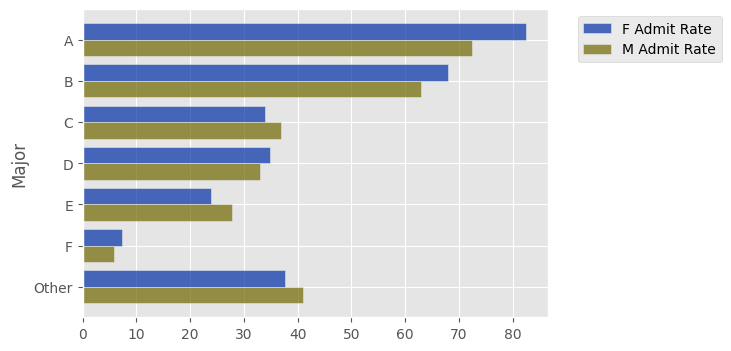

In [8]:
#Run this cell to create the admit_by_dept_rate table from Question 6 Workshop 2. Do not edit this cell.
admit_by_dept = cal_data.where("Admission", "Admitted").pivot('Gender', 'Major')
count_by_dept = cal_data.pivot('Gender', 'Major')

admit_f_by_dept_rate = admit_by_dept.column("F")/count_by_dept.column("F") * 100
admit_m_by_dept_rate = admit_by_dept.column("M")/count_by_dept.column("M") * 100

admit_by_dept_rate = Table().with_columns(
                        "Major", admit_by_dept.column("Major"),
                        "F Admit Rate", admit_f_by_dept_rate,
                        "M Admit Rate", admit_m_by_dept_rate)
admit_by_dept_rate.barh("Major")

<div style="background-color: #fff3cd; border: 1px solidrgb(21, 176, 253); border-radius: 4px; padding: 12px 16px; margin: 8px 0;">
We will be prompting Gemini to generate this same plot later on in Question 3!
<div>

## Converting Table Contents Into Strings

Although we have loaded in `cal_data` in the previous section, remember that `contents` in the API call takes in **strings** data types and `cal_data` has a data type of a **datascience table**. 

In order to pass in `cal_data` into `contents` argument of the API call, we will need to convert the contents in the `cal_data` table into **strings** in the next cell.

In [21]:
# Run this cell to convert the contents in the `cal_data` table into strings
with open("UCBerkeley1973_Admission.csv", 'r') as f:
    table_contents = f.read()

In [22]:
# Run this cell and notice how the output of `table_contents` is a list of string of all the contents in the `cal_data` table.
table_contents

'Year,Major,Gender,Admission\n1973,C,F,Rejected\n1973,B,M,Admitted\n1973,Other,F,Admitted\n1973,Other,M,Admitted\n1973,Other,M,Rejected\n1973,Other,M,Rejected\n1973,F,F,Admitted\n1973,Other,M,Admitted\n1973,Other,M,Rejected\n1973,A,M,Admitted\n1973,Other,F,Rejected\n1973,B,M,Admitted\n1973,C,M,Rejected\n1973,A,M,Rejected\n1973,Other,M,Rejected\n1973,Other,F,Rejected\n1973,A,M,Admitted\n1973,Other,F,Admitted\n1973,Other,M,Rejected\n1973,F,M,Rejected\n1973,Other,M,Rejected\n1973,C,M,Admitted\n1973,C,F,Rejected\n1973,Other,M,Rejected\n1973,Other,F,Rejected\n1973,Other,M,Rejected\n1973,Other,M,Rejected\n1973,Other,M,Rejected\n1973,C,M,Rejected\n1973,Other,M,Rejected\n1973,Other,M,Admitted\n1973,F,F,Rejected\n1973,F,M,Rejected\n1973,D,M,Rejected\n1973,Other,M,Rejected\n1973,Other,F,Rejected\n1973,Other,F,Rejected\n1973,C,F,Admitted\n1973,Other,M,Rejected\n1973,Other,M,Admitted\n1973,A,M,Rejected\n1973,Other,M,Admitted\n1973,A,M,Admitted\n1973,A,M,Rejected\n1973,Other,M,Rejected\n1973,Other,

In [23]:
# Run this cell to create the `table_info` variable that contains the information about the `cal_data` table.
table_info = "The table cal_data has columns Year, Major, Gender (F or M), Admission (Admitted or Rejected)"
table_info

'The table cal_data has columns Year, Major, Gender (F or M), Admission (Admitted or Rejected)'

## [Tutorial] `num_applicants` 

In the code cell below, we created an API call that will give the **number of total applicants** in `cal_data` using the variables `table_contents` and `table_info` that we have defined above.

<div style="background-color:rgb(248, 51, 47); border: 1px solidrgb(21, 176, 253); border-radius: 4px; padding: 12px 16px; margin: 8px 0;">
It seems like the LLM is guessing on the number 4526 instead of counting the number of rows there are within the `table_contents` strings. 
When I tried prompting it to use len(table_contents.strip().splitlines() - 1), it still gave the wrong answer. 
Should we keep this as a part of "Hallucination" example? 
<div>

In [94]:
num_applicant_task = "Return the number of total applicants in the table cal_data."

In [95]:
# Run this cell to see the result of the API call

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents= [
        table_contents,
        num_applicant_task
    ]
)
print(response.text)

The total number of applicants in the table is 4526.


In [71]:
# run the cell below to verify the result of the API call
num_applicants = cal_data.num_rows
print("The number of total applicants in the table cal_data is:", num_applicants)

The number of total applicants in the table cal_data is: 12763


> Note: Without context, LLMs are not able to generate correctly.

## Question 2: `num_admitted`

Replace `...` below in `q2_contents` that will give the number of **admitted** students from the table `cal_data`.

**HINT:** Remember what the `contents` argument must be. You may find either `table_contents` or `table_info` that we have defined earlier helpful.

In [136]:
#TODO: replace ... with your prompt
q2_contents = """
        ... 
"""
# Do not edit anything below this line
print("This is the promot you will be passing into the API call in the next cell:", q2_contents)

This is the promot you will be passing into the API call in the next cell: 
        ... 



In [ ]:
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents= q2_contents #from the cell above
)
print(response.text)

In [135]:
# run the cell below to verify the result of the API call
num_admitted = cal_data.where("Admission", "Admitted").num_rows

print("The number of admitted students in the table cal_data is:", num_admitted)

The number of admitted students in the table cal_data is: 5232


## [Tutorial] LLM writes plotting code (without contexts)

In [102]:
q_without_context = "Generate a function called paradox_barh that takes cal_data as an input and displays a horizontal bar chart of the admit rates respectively to their gender and major"

In [103]:
 # Reload so cal_data is a datascience Table (pasted LLM code below may overwrite this name with other types of tables)
output_format = ("Give a complete, runnable Python code only (no truncation with ...) that user can copy and paste into another notebook cell without depending on other cells.",
                 "Do not add ```python or ``` at the beginning or end of your code.",
                 "Do not make any assumptions about the data instead make sure you provide all code necessary to run the code without depending on the other cells",
                 "Do not show me what the provided table is, you are only allowed to just give me the code to make the plot")

response = client.models.generate_content(
    model="gemini-3.5-flash",
    contents=[
        table_info,
        q_without_context,
        output_format
    ]
)

print(response.text)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def paradox_barh(cal_data):
    # Create a copy to avoid SettingWithCopyWarning
    df = cal_data.copy()
    
    # Convert Admission to binary (1 for Admitted, 0 for Rejected)
    df['Is_Admitted'] = (df['Admission'] == 'Admitted').astype(int)
    
    # Calculate admission rate by Major and Gender
    # Group by Major and Gender, calculate mean, and unstack Gender to columns
    admit_rates = df.groupby(['Major', 'Gender'])['Is_Admitted'].mean().unstack()
    
    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    admit_rates.plot(kind='barh', ax=ax, color=['#ff9999', '#66b3ff'])
    
    # Formatting the chart
    ax.set_title('Admission Rates by Major and Gender', fontsize=14, fontweight='bold')
    ax.set_xlabel('Admission Rate', fontsize=12)
    ax.set_ylabel('Major', fontsize=12)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(0, 1)
    

> **Note:** It is okay if code pasted from an LLM raises an error.
>
> LLMs do not have full context about your notebook state, installed packages, variable names, or file paths unless you provide that context explicitly. Treat generated code as a draft: run it, inspect errors, and revise prompts or code iteratively.

Press the three dots on the left side of the outputted cell above, select "Copy Cell Output", and paste the code below:**

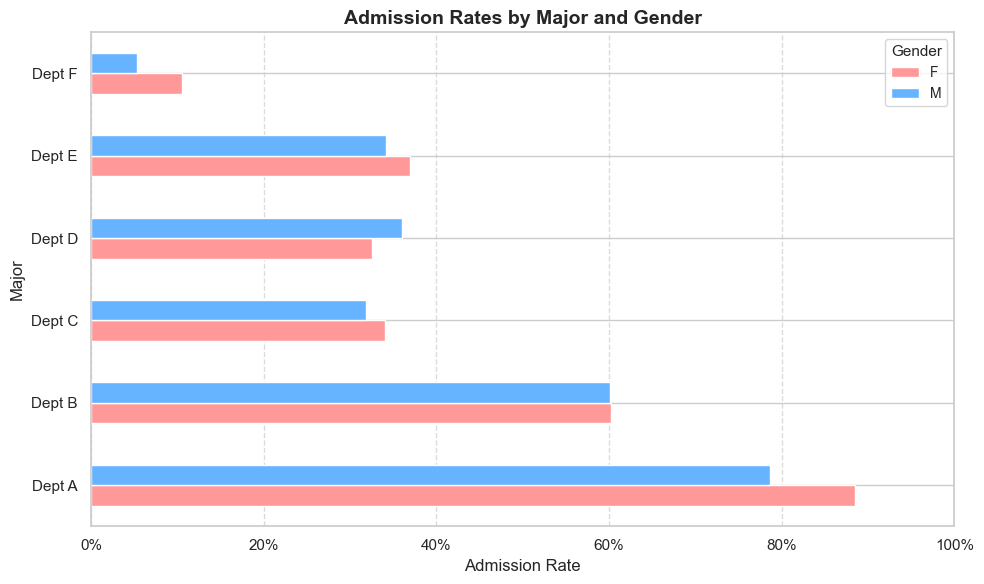

In [104]:
#TODO: replace the ... with the code from the LLM 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def paradox_barh(cal_data):
    # Create a copy to avoid SettingWithCopyWarning
    df = cal_data.copy()
    
    # Convert Admission to binary (1 for Admitted, 0 for Rejected)
    df['Is_Admitted'] = (df['Admission'] == 'Admitted').astype(int)
    
    # Calculate admission rate by Major and Gender
    # Group by Major and Gender, calculate mean, and unstack Gender to columns
    admit_rates = df.groupby(['Major', 'Gender'])['Is_Admitted'].mean().unstack()
    
    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    admit_rates.plot(kind='barh', ax=ax, color=['#ff9999', '#66b3ff'])
    
    # Formatting the chart
    ax.set_title('Admission Rates by Major and Gender', fontsize=14, fontweight='bold')
    ax.set_xlabel('Admission Rate', fontsize=12)
    ax.set_ylabel('Major', fontsize=12)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(0, 1)
    ax.legend(title='Gender', fontsize=10, title_fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Generate dummy data to make the code fully runnable
np.random.seed(42)
n_samples = 2000
majors = ['Dept A', 'Dept B', 'Dept C', 'Dept D', 'Dept E', 'Dept F']
genders = ['F', 'M']
years = [2021, 2022, 2023]

# Generate realistic biased data to simulate Simpson's Paradox
data = []
for _ in range(n_samples):
    year = np.random.choice(years)
    major = np.random.choice(majors, p=[0.25, 0.20, 0.15, 0.15, 0.15, 0.10])
    
    # Assign gender and admission probabilities that differ by major (Simpson's Paradox setup)
    if major == 'Dept A':
        gender = np.random.choice(genders, p=[0.1, 0.9])
        admission = np.random.choice(['Admitted', 'Rejected'], p=[0.8, 0.2])
    elif major == 'Dept B':
        gender = np.random.choice(genders, p=[0.2, 0.8])
        admission = np.random.choice(['Admitted', 'Rejected'], p=[0.6, 0.4])
    elif major == 'Dept F':
        gender = np.random.choice(genders, p=[0.8, 0.2])
        admission = np.random.choice(['Admitted', 'Rejected'], p=[0.1, 0.9])
    else:
        gender = np.random.choice(genders, p=[0.5, 0.5])
        admission = np.random.choice(['Admitted', 'Rejected'], p=[0.35, 0.65])
        
    data.append([year, major, gender, admission])

# Create the cal_data DataFrame
cal_data = pd.DataFrame(data, columns=['Year', 'Major', 'Gender', 'Admission'])

# Execute the function to display the chart
paradox_barh(cal_data)

## Hallucination

**Hallucination** is when the model generates plausible-looking output that is not faithful to the task requirements.

In this activity, hallucination can look like:
- using libraries other than `datascience`
- **making up random data**
- returning the wrong function name/signature
- using different column labels
- making a stacked chart instead of an overlaid chart
- adding extra explanation text instead of only code

## Why Context Matters 
After adding explicit context in the prompt (dataset schema, allowed library, exact function name, exact relabel strings, chart type, and output format constraints), Gemini is much less likely to hallucinate because the solution space is tightly bounded.

So the key lesson is: we did not "make the model smarter"; we made the task specification precise enough that the model can follow it reliably.

<hr style="border: 1px solid #fdb515;" />


## Question 3: LLM writes plotting code (with contexts)

Now you will be asking Gemini to write a complete Python function called `paradox_barh(cal_data)` that reproduces the bar chart above from **Simpson’s paradox** style admissions data in Workshop 2.

**Question:** Make sure your `question` variable includes the following:

- Clearly state the function name and its input parameter(s).
- Specify what the function should display or return regarding the number of applicants (e.g., an overlaid bar chart).
- Mention the dataset columns relevant for the plot (e.g., gender, major).
- Indicate the use of overlaid bars (not stacked) with a bar chart.

**Model:** Please use `gemini-2.5-flash`

**TASK:** **Please replace `...` with your **prompt string** and **model string**.**

<details>
<summary><b>HINT: Expand this cell to see an example sentence for the <code>question</code> and <code>contents</code> variables that correctly generates the plot we want.</b></summary>

```python
question = "Generate a function called paradox_barh that takes cal_data as an input and displays a horizontal bar chart of the admit rates respectively to their gender and major"

contents = """
    - Dataset: The table cal_data has columns Year, Major, Gender (F or M), Admission (Admitted or Rejected) and the data is loaded in for you.
    - You are only allowed to use `.pivot`, `.where`, and `.barh` from the datascience library in your code.
    - Datascience Library details:
     * datascience Table.pivot(columns, rows): the FIRST argument's unique values become column headers; the SECOND argument's unique values become the row labels (the leftmost column).
     * datascience Table.where(column, value): the FIRST argument is the column name and the SECOND argument is the value to filter the table by
     * datascience Table.barh(column): the argument is the column name to display on the horizontal axis.
    - Do not include any other text than the function definition. Do not include texts like comments, etc.
    - Calculate the admission percentages(between 0 and 100) of female and males to each department using the dataset from cal_data.
    - Make sure to store intermediate tables in variables.
    - The values of Gender should be the columns of the pivot table and the values of Majors should be the rows of the pivot table.
    - Make sure that the x-axis is Major and the legend is F Admit Rate and M Admit Rate.
    - The function should take in a table and display a horizontal bar chart, and another line of code that passes in cal_data to the function.
    - Make sure the code is where the user can just copy and paste the code into a notebook cell and run it.
    - Do not put any documentation or comments in the code.
    - Do not include ```python or ``` at the beginning or end of your code.
"""
```

</details>

In [ ]:
question = "..." #TODO: fill in the prompt
model = "..." #TODO: fill in the model name

In [ ]:
#TODO: fill in the contexts you think are necessary to produce the correct bar graph like the on in Workshop 2
w_contexts = """
    ...
"""

In [ ]:
cal_data = Table.read_table('UCBerkeley1973_Admission.csv') #load the dataset again to ensure it is a datascience table
preview = str(cal_data.take(5))  #preview of the cal_data table 

response = client.models.generate_content(
    model= model,
    contents=[
        f"Sample rows (for context only):\n{preview}",
        question,
        w_contexts
    ]
)
print(response.text)

### QUESTION 3 SOLUTION

In [24]:
question = "Generate a function called paradox_barh that takes cal_data as an input and displays a horizontal bar chart of the admit rates respectively to their gender and major"
model = "gemini-2.5-flash"


In [25]:
w_contexts = """
    - Dataset: The table cal_data has columns Year, Major, Gender (F or M), Admission (Admitted or Rejected) and the data is loaded in for you.
    - You are only allowed to use `.pivot`, `.where`, and `.barh` from the datascience library in your code.
    - Datascience Library details:
     * datascience Table.pivot(columns, rows): the FIRST argument's unique values become column headers; the SECOND argument's unique values become the row labels (the leftmost column).
     * datascience Table.where(column, value): the FIRST argument is the column name and the SECOND argument is the value to filter the table by
     * datascience Table.barh(column): the argument is the column name to display on the horizontal axis.
    - Do not include any other text than the function definition. Do not include texts like comments, etc.
    - Calculate the admission percentages(between 0 and 100) of female and males to each department using the dataset from cal_data.
    - Make sure to store intermediate tables in variables.
    - The values of Gender should be the columns of the pivot table and the values of Majors should be the rows of the pivot table.
    - Make sure that the x-axis is Major, the y-axis is Admit Rate, and the legend is F Admit Rate and M Admit Rate.
    - The function should take in a table and display a horizontal bar chart, and another line of code that passes in cal_data to the function.
    - Make sure the code is where the user can just copy and paste the code into a notebook cell and run it.
    - Do not put any documentation or comments in the code.
    - Do not include ```python or ``` at the beginning or end of your code.
    - Do NOT comment out the last line that calls the function on cal_data.
"""

In [ ]:
#please do not edit anything in this cell
cal_data = Table.read_table('UCBerkeley1973_Admission.csv') #load the dataset again to ensure it is a datascience table
table_preview = str(cal_data.take(20))  #preview of the cal_data table 

response = client.models.generate_content(
    model= model,
    contents=[
        question,
        w_contexts,
        table_preview
    ]
)
print(response.text)

from datascience import Table
import numpy as np

def paradox_barh(cal_data):
    total_applicants_by_major_gender = cal_data.pivot(columns='Gender', rows='Major')

    admitted_data = cal_data.where('Admission', 'Admitted')

    admitted_applicants_by_major_gender = admitted_data.pivot(columns='Gender', rows='Major')

    total_F_applicants = total_applicants_by_major_gender.column('F')
    total_M_applicants = total_applicants_by_major_gender.column('M')

    admitted_F_students = admitted_applicants_by_major_gender.column('F')
    admitted_M_students = admitted_applicants_by_major_gender.column('M')

    f_admit_rate = (admitted_F_students / total_F_applicants) * 100
    m_admit_rate = (admitted_M_students / total_M_applicants) * 100

    majors_list = total_applicants_by_major_gender.column('Major')

    final_admit_rates_table = Table().with_columns(
        'Major', majors_list,
        'F Admit Rate', f_admit_rate,
        'M Admit Rate', m_admit_rate
    )

    final_admit_rate

In [32]:
#please do not edit anything in this cell
cal_data = Table.read_table('UCBerkeley1973_Admission.csv') #load the dataset again to ensure it is a datascience table
table_preview = str(cal_data.take(20))  #preview of the cal_data table 

response = client.models.generate_content(
    model= model,
    contents=[
        question,
        w_contexts,
        table_preview
    ]
)
print(response.text)

from datascience import Table

def paradox_barh(cal_data):
    total_applicants_pivot = cal_data.pivot('Gender', 'Major')
    admitted_data = cal_data.where('Admission', 'Admitted')
    admitted_counts_pivot = admitted_data.pivot('Gender', 'Major')

    majors = total_applicants_pivot.column('Major')

    total_f = total_applicants_pivot.column('F')
    total_m = total_applicants_pivot.column('M')

    admitted_f = admitted_counts_pivot.column('F')
    admitted_m = admitted_counts_pivot.column('M')

    f_admit_rate_percent = (admitted_f / total_f) * 100
    m_admit_rate_percent = (admitted_m / total_m) * 100

    admit_rates_table = Table().with_columns(
        'Major', majors,
        'F Admit Rate', f_admit_rate_percent,
        'M Admit Rate', m_admit_rate_percent
    )

    admit_rates_table.barh('Major')

paradox_barh(cal_data)


**Test the model’s code:** paste the function into the cell below (or edit that cell until it runs), then run it.

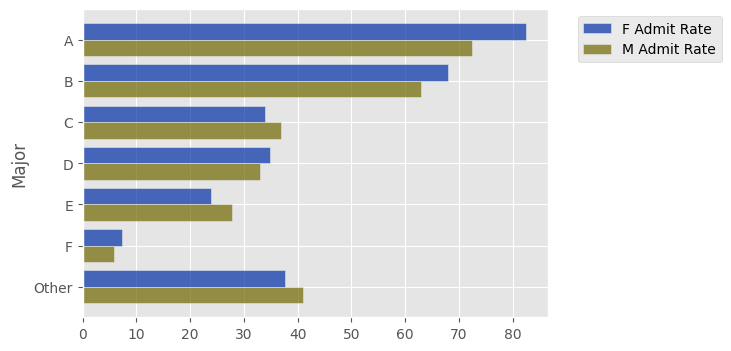

In [33]:
#TODO: copy and paste the code from the LLM to replace ... 
# and see if the model correctly made the function that generates the correct bart chart.

from datascience import Table

def paradox_barh(cal_data):
    total_applicants_pivot = cal_data.pivot('Gender', 'Major')
    admitted_data = cal_data.where('Admission', 'Admitted')
    admitted_counts_pivot = admitted_data.pivot('Gender', 'Major')

    majors = total_applicants_pivot.column('Major')

    total_f = total_applicants_pivot.column('F')
    total_m = total_applicants_pivot.column('M')

    admitted_f = admitted_counts_pivot.column('F')
    admitted_m = admitted_counts_pivot.column('M')

    f_admit_rate_percent = (admitted_f / total_f) * 100
    m_admit_rate_percent = (admitted_m / total_m) * 100

    admit_rates_table = Table().with_columns(
        'Major', majors,
        'F Admit Rate', f_admit_rate_percent,
        'M Admit Rate', m_admit_rate_percent
    )

    admit_rates_table.barh('Major')

paradox_barh(cal_data)

**Compare** the model's code with your code from Workshop 2 below:

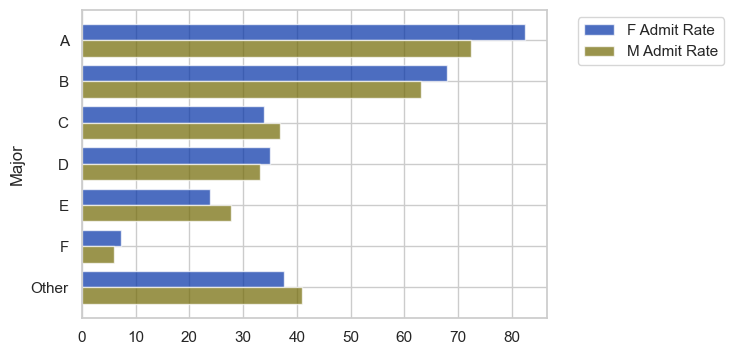

In [110]:
admit_by_dept_rate.barh("Major")

## Prompt engineering resources

* [Gemini API: Prompting Strategies](https://ai.google.dev/gemini-api/docs/prompting-strategies)
* [Ziem et al., Table 1](https://direct.mit.edu/view-large/figure/4722326/coli_a_00502_i004.tif)


<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />
